## Q1

In [1]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures

mobile = pd.DataFrame({
    "RAM": [4, 6, 8, 12],
    "Storage": [64, 128, 256, 512]
})

print("Original Data:")
print(mobile)

poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(mobile)

feature_names = poly.get_feature_names_out(["RAM", "Storage"])

poly_df = pd.DataFrame(poly_features, columns=feature_names)

print("\nPolynomial Feature Matrix:")
print(poly_df)

Original Data:
   RAM  Storage
0    4       64
1    6      128
2    8      256
3   12      512

Polynomial Feature Matrix:
    RAM  Storage  RAM^2  RAM Storage  Storage^2
0   4.0     64.0   16.0        256.0     4096.0
1   6.0    128.0   36.0        768.0    16384.0
2   8.0    256.0   64.0       2048.0    65536.0
3  12.0    512.0  144.0       6144.0   262144.0


## Q2

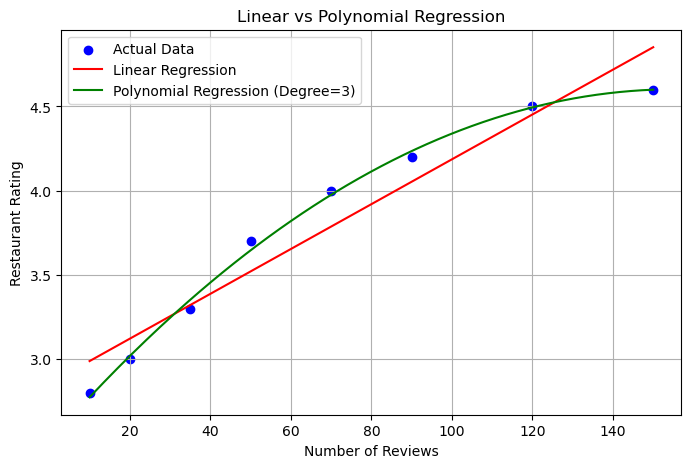

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

reviews = np.array([10, 20, 35, 50, 70, 90, 120, 150]).reshape(-1,1)
ratings = np.array([2.8, 3.0, 3.3, 3.7, 4.0, 4.2, 4.5, 4.6])

linear = LinearRegression()
linear.fit(reviews, ratings)

poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(reviews)

poly_model = LinearRegression()
poly_model.fit(X_poly, ratings)

x_range = np.linspace(10,150,200).reshape(-1,1)

plt.figure(figsize=(8,5))
plt.scatter(reviews, ratings, color="blue", label="Actual Data")

plt.plot(x_range,
         linear.predict(x_range),
         color="red",
         label="Linear Regression")

plt.plot(x_range,
         poly_model.predict(poly.transform(x_range)),
         color="green",
         label="Polynomial Regression (Degree=3)")

plt.xlabel("Number of Reviews")
plt.ylabel("Restaurant Rating")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.grid(True)
plt.show()

## Q3

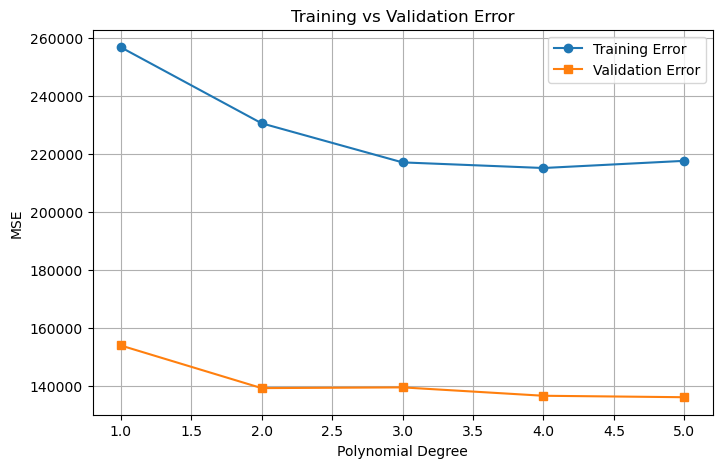

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

np.random.seed(42)

followers = np.linspace(100,1000,100)
posts = 0.002*followers**2 + np.random.normal(0,500,100)

X = followers.reshape(-1,1)
y = posts

X_train,X_val,y_train,y_val = train_test_split(
    X,y,test_size=0.3,random_state=42
)

train_error=[]
val_error=[]

for d in range(1,6):

    poly = PolynomialFeatures(degree=d)

    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)

    model = LinearRegression()

    model.fit(X_train_poly,y_train)

    train_pred=model.predict(X_train_poly)
    val_pred=model.predict(X_val_poly)

    train_error.append(mean_squared_error(y_train,train_pred))
    val_error.append(mean_squared_error(y_val,val_pred))

plt.figure(figsize=(8,5))
plt.plot(range(1,6),train_error,marker='o',label="Training Error")
plt.plot(range(1,6),val_error,marker='s',label="Validation Error")

plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Training vs Validation Error")
plt.legend()
plt.grid(True)
plt.show()

## Q4

In [4]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

RAM = np.array([4,6,8,12,16,8,6,12]).reshape(-1,1)
Price = np.array([15000,22000,28000,42000,70000,38000,21000,68000])

X_train,X_test,y_train,y_test = train_test_split(
    RAM,Price,test_size=0.25,random_state=42
)

poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

linear = LinearRegression()
linear.fit(X_train_poly,y_train)

pred1 = linear.predict(X_test_poly)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_poly,y_train)

pred2 = ridge.predict(X_test_poly)

print("Polynomial Regression Test MSE:",
      mean_squared_error(y_test,pred1))

print("Ridge Regression Test MSE:",
      mean_squared_error(y_test,pred2))

Polynomial Regression Test MSE: 40520388.672352865
Ridge Regression Test MSE: 22161474.72385502


## Q5

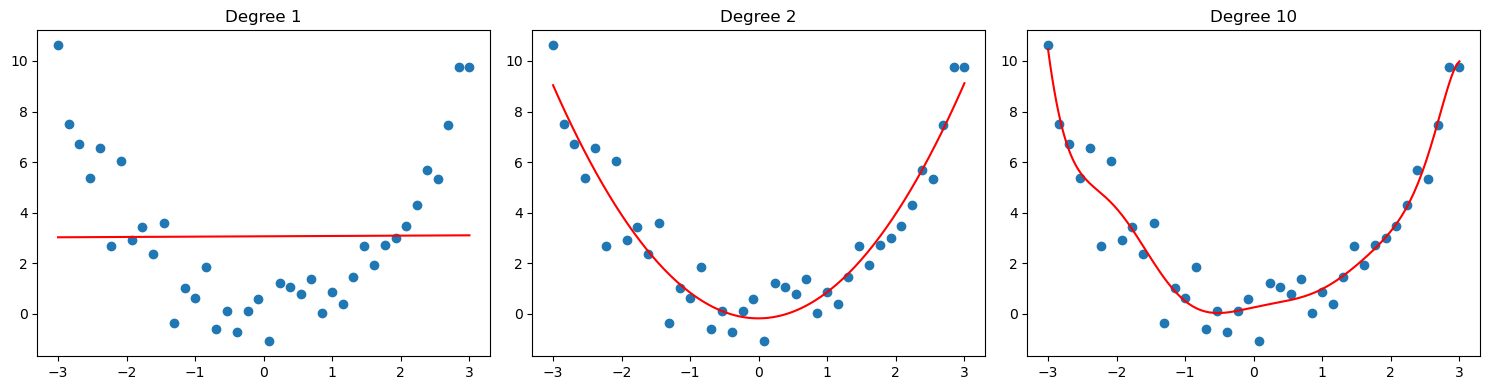

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

np.random.seed(1)

X = np.linspace(-3,3,40)
y = X**2 + np.random.normal(0,1,40)

X = X.reshape(-1,1)

degrees = [1,2,10]

plt.figure(figsize=(15,4))

for i,d in enumerate(degrees):

    poly = PolynomialFeatures(degree=d)

    X_poly = poly.fit_transform(X)

    model = LinearRegression()

    model.fit(X_poly,y)

    X_plot = np.linspace(-3,3,200).reshape(-1,1)

    y_plot = model.predict(poly.transform(X_plot))

    plt.subplot(1,3,i+1)

    plt.scatter(X,y)
    plt.plot(X_plot,y_plot,color='red')

    plt.title(f"Degree {d}")

plt.tight_layout()
plt.show()